In [281]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import mannwhitneyu
import statsmodels.api as sm
from statsmodels.formula.api import ols
import gsw

In [304]:
sns.set_context("notebook",
               font_scale = 1.5,
               rc = {"lines.linewidth":2.5})
params = {"ytick.color" : "k",
          "xtick.color" : "k",
          "axes.labelcolor" : "k",
          "axes.edgecolor" : "k",
         "text.color":"k"}
plt.rcParams.update(params)

In [283]:
stationdict = {"highnitrite":np.arange(1,30),
               "lownitrite":np.arange(30,72)}  # in sigma0

In [317]:
data = pd.read_csv("data_clean.csv")
data[np.isin(data.Station, stationdict["highnitrite"])].Date.unique().max()

'2022-11-01'

In [284]:
# Load Data
data = pd.read_csv("data_clean.csv")
data = data[
    [
        "Station",
        "Depth",
        "lon",
        "lat",
        "T",
        "S",
        "P",
        "O2",
        "sigma0",
        "rho",
        "DIC",
        "DIP",
        "NO3",
        "NO2"
    ]
]

data = data[(data.Station != 47)&
           (data.Station != 58)]

# Calculate AOU
SA = gsw.SA_from_SP(data["S"], data["P"], data["lon"], data["lat"])
PT = gsw.pt0_from_t(SA, data["T"], data["P"])
O2sat = gsw.O2sol_SP_pt(data["S"], PT)
AOU = O2sat - data["O2"]
data["AOU"] = AOU
data["DIN"] = data["NO3"] + data["NO2"]

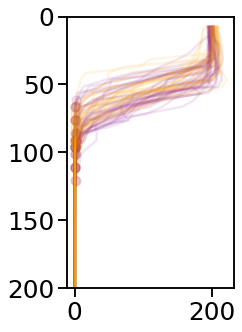

In [285]:
stationlistlow = stationdict["lownitrite"]
stationlisthigh = stationdict["highnitrite"]

upperinterfacedepths = []
lowerinterfacedepths = []
upperinterfacesigmas = []
lowerinterfacesigmas = []

fig, ax = plt.subplots(1,1, figsize = (3,5))
for s in stationlistlow:
    stationdata = data[data.Station == s].sort_values("Depth")
    if len(stationdata) > 0:
        int1 = stationdata[stationdata.O2 < 2].sort_values('Depth').iloc[0]
        int2 = stationdata[stationdata.O2 < 2].sort_values('Depth').iloc[-1]
        upperinterfacedepths.append(int1.Depth)
        lowerinterfacedepths.append(int2.Depth)
        upperinterfacesigmas.append(int1.sigma0)
        lowerinterfacesigmas.append(int2.sigma0)
        ax.plot(np.array(stationdata.O2), np.array(stationdata.Depth),
                color = "purple", label = "low nitrite", alpha = 0.1)
        ax.scatter(int1.O2, int1.Depth, color = "purple", label = "low nitrite", alpha = 0.1)
        ax.scatter(int2.O2, int2.Depth, color = "purple", label = "low nitrite", alpha = 0.1)

for s in stationlisthigh:
    stationdata = data[data.Station == s].sort_values("Depth")
    if len(stationdata) > 0:
        int1 = stationdata[stationdata.O2 < 2].sort_values('Depth').iloc[0]
        int2 = stationdata[stationdata.O2 < 2].sort_values('Depth').iloc[-1]
        upperinterfacedepths.append(int1.Depth)
        lowerinterfacedepths.append(int2.Depth)
        upperinterfacesigmas.append(int1.sigma0)
        lowerinterfacesigmas.append(int2.sigma0)
        ax.plot(np.array(stationdata.O2), np.array(stationdata.Depth),
                color = "orange", label = "high nitrite", alpha = 0.1)
        ax.scatter(int1.O2, int1.Depth, color = "orange", label = "high nitrite", alpha = 0.1)
        ax.scatter(int2.O2, int2.Depth, color = "orange", label = "high nitrite", alpha = 0.1)

ax.set_ylim([200,0])

upperinterfacedepth = np.mean(upperinterfacedepths)
lowerinterfacedepth = np.mean(lowerinterfacedepths)
upperinterfacesigma = np.mean(upperinterfacesigmas)
lowerinterfacesigma = np.mean(lowerinterfacesigmas)

In [286]:
stationdata[stationdata.O2 < 2].sort_values('Depth').iloc[0]

Station      29.000000
Depth        66.591000
lon         253.010000
lat          17.038000
T            16.659300
S            34.695400
P            67.000000
O2            0.920000
sigma0       25.368306
rho        1025.661393
DIC        2260.000000
DIP           2.293087
NO3          27.020000
NO2           0.000000
AOU         239.571632
DIN          27.020000
Name: 2012, dtype: float64

In [287]:
stationdata[stationdata.O2 < 2].sort_values('Depth').iloc[-1]

Station      29.000000
Depth       794.644000
lon         253.010000
lat          17.038000
T             5.486500
S            34.526200
P           800.940000
O2            0.760000
sigma0       27.259336
rho        1030.923888
DIC        2354.000000
DIP           3.304284
NO3          42.820000
NO2           0.000000
AOU         304.659918
DIN          42.820000
Name: 1969, dtype: float64

In [288]:
columndict = {"# DNRN":"DNRN",
        " Anammox":"anammox",
        " Denitrification":"denitrification",
        " Nitrite Oxidation":"nitrox",
        " CaCO3 Dissolution ":"caco3diss"}

chunklow = "lownitrite"
chunkhigh = "highnitrite"
layer = 1
param = "DNRN"
labellow = f"{chunklow}\nlayer {layer}"
labelhigh = f"{chunkhigh}\nlayer {layer}"

slopeslow = pd.read_excel(f"output/chunk{chunklow}/slopesDF.xlsx")
slopeshigh = pd.read_excel(f"output/chunk{chunkhigh}/slopesDF.xlsx")

In [289]:
from scipy.stats import t
pvals = np.ones(slopeslow.shape[0])

for layer in list(slopeslow.index):
    slope1 = slopeslow.iloc[layer].NstarvsDICslope
    se1 = slopeslow.iloc[layer].NstarvsDICerr
    n1 = slopeslow.iloc[layer].n
    k1 = 2
    
    slope2 = slopeshigh.iloc[layer].NstarvsDICslope
    se2 = slopeshigh.iloc[layer].NstarvsDICerr
    n2 = slopeshigh.iloc[layer].n
    k2 = 2
    
    # Test statistic
    t_stat = (slope1 - slope2) / np.sqrt(se1**2 + se2**2)
    
    # Degrees of freedom (Welch–Satterthwaite)
    numerator = (se1**2 + se2**2)**2
    denominator = (se1**4)/(n1 - k1) + (se2**4)/(n2 - k2)
    df = numerator / denominator
    
    # Two-tailed p-value
    p = 2 * (1 - t.cdf(abs(t_stat), df))
    pvals[layer] = p
    
    print(f"t = {t_stat:.3f}, df = {df:.1f}, p = {p:.4f}")

idx_sig = np.where(pvals <= 0.001)

t = -4.207, df = 103.7, p = 0.0001
t = -1.164, df = 117.9, p = 0.2466
t = -1.628, df = 125.0, p = 0.1060
t = -3.004, df = 186.4, p = 0.0030
t = -3.217, df = 189.2, p = 0.0015
t = -3.931, df = 226.6, p = 0.0001
t = 3.183, df = 992.6, p = 0.0015
t = 6.152, df = 301.3, p = 0.0000


In [290]:
idx_sig

(array([0, 5, 7]),)

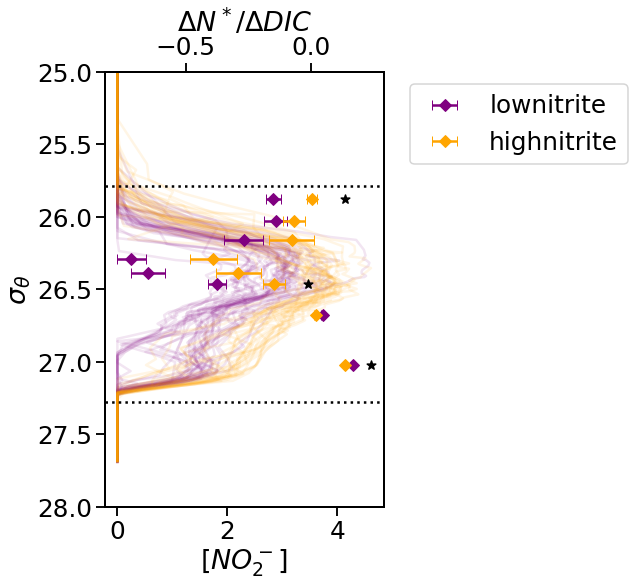

In [291]:
stationlistlow = stationdict["lownitrite"]
stationlisthigh = stationdict["highnitrite"]

chunklow = "lownitrite"
chunkhigh = "highnitrite"

fig, ax = plt.subplots(1,1, figsize = (5,8))
for s in stationlistlow:
    stationdata = data[data.Station == s].sort_values("sigma0")
    if len(stationdata) > 0:
        ax.plot(np.array(stationdata.NO2), np.array(stationdata.sigma0),
                color = "purple", label = None, alpha = 0.1, zorder = 0)

for s in stationlisthigh:
    stationdata = data[data.Station == s].sort_values("sigma0")
    if len(stationdata) > 0:
        ax.plot(np.array(stationdata.NO2), np.array(stationdata.sigma0),
                color = "orange", label = None, alpha = 0.1, zorder = 0)

ax.set_ylim([28,25])
ax.set_xlabel(r"[$NO_2^-$]")

ax2 = ax.twiny()
ax2.errorbar(slopeslow.NstarvsDICslope, slopeslow.sigma0,
            xerr = slopeslow.NstarvsDICerr, label = r"Low $NO_2^-$", color = "purple",
           marker = "D", linestyle = "none", capsize = 5, zorder = 1)
ax2.errorbar(slopeshigh.NstarvsDICslope, slopeshigh.sigma0,
            xerr = slopeshigh.NstarvsDICerr, label = r"High $NO_2^-$", color = "orange",
           marker = "D", linestyle = "none", capsize = 5, zorder = 2)

ax2.scatter(slopeshigh.NstarvsDICslope.iloc[idx_sig] + slopeslow.NstarvsDICerr.iloc[idx_sig] + 0.1,
            slopeshigh.sigma0.iloc[idx_sig], marker = "*", color = "k")

ax2.legend(bbox_to_anchor = (1.05, 1.0), loc = "upper left")
ax2.set_ylim([28,25])
ax2.set_xlabel(r"$\delta*100 N^*/\delta*100 DIC$")
ax.set_ylabel(r"$\sigma_{\theta}$")

ax2.axhline(upperinterfacesigma, color = "k", linestyle = ":")
ax2.axhline(lowerinterfacesigma, color = "k", linestyle = ":")

In [302]:
ls

5906484qcno2.txt                     figures/
5906484qcno2PO4.txt                  formatdata.py
5906484qcno2_updated.txt             grid_WOA_phosphate.py
CANYONB_output.csv                   input_for_CANYONB.csv
O2_map_plot.py                       model statistics.ipynb
README.txt                           output/
bottle_data.csv                      pH_and_reactions.py
calc_argo_outputs.ipynb              pH_and_reactions_Cox.py
calc_argo_outputs.py                 plot_Cox_outputs_compared.py
calc_falkor_outputs.py               plot_argo_results_Cox.py
calc_falkor_outputs_func.py          plot_falkor_results_Cox.py
calc_oxycline_features.py            plot_multiple_p18_profiles.py
calc_oxycline_features_argo.ipynb    plot_sections.ipynb
calc_reaction_stoi_and_R.py          plot_st9.py
calcium_carbonate_saturation.py      plot_station_no2_and_pH.py
clean_argo.py                        plot_tracer_profiles.py
clean_falkor.py                      satelite imagery over time.pptx
dat

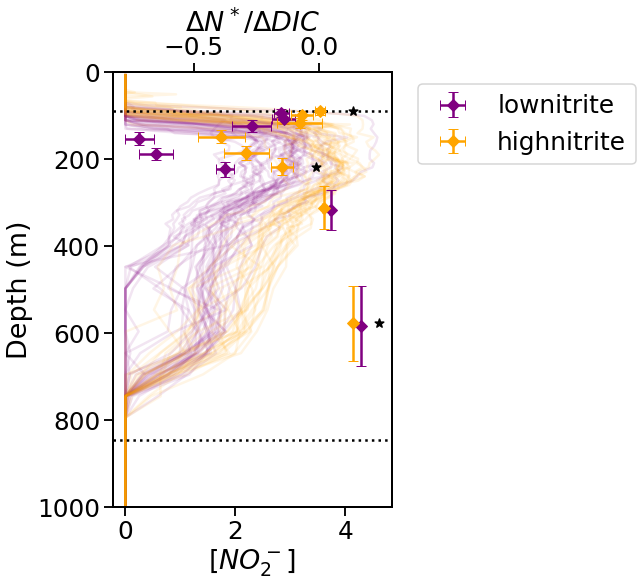

In [292]:
stationlistlow = stationdict["lownitrite"]
stationlisthigh = stationdict["highnitrite"]

chunk1 = "lownitrite"
chunk2 = "highnitrite"

fig, ax = plt.subplots(1,1, figsize = (5,8))
for s in stationlistlow:
    stationdata = data[data.Station == s].sort_values("Depth")
    if len(stationdata) > 0:
        ax.plot(np.array(stationdata.NO2), np.array(stationdata.Depth),
                color = "purple", label = None, alpha = 0.1)

for s in stationlisthigh:
    stationdata = data[data.Station == s].sort_values("Depth")
    if len(stationdata) > 0:
        ax.plot(np.array(stationdata.NO2), np.array(stationdata.Depth),
                color = "orange", label = None, alpha = 0.1)
ax.set_ylim([1000,0])
ax.set_xlabel(r"[$NO_2^-$]")

ax2 = ax.twiny()
ax2.errorbar(slopeslow.NstarvsDICslope, slopeslow.depth,
            xerr = slopeslow.NstarvsDICerr, yerr = slopeslow.deptherr, label = r"Low $NO_2^-$", color = "purple",
           marker = "D", linestyle = "none", capsize = 5)
ax2.errorbar(slopeshigh.NstarvsDICslope, slopeshigh.depth,
            xerr = slopeshigh.NstarvsDICerr, yerr = slopeshigh.deptherr, label = r"High $NO_2^-$", color = "orange",
           marker = "D", linestyle = "none", capsize = 5)

ax2.scatter(slopeshigh.NstarvsDICslope.iloc[idx_sig] + slopeslow.NstarvsDICerr.iloc[idx_sig] + 0.1,
            slopeshigh.depth.iloc[idx_sig], marker = "*", color = "k")


ax2.legend(bbox_to_anchor = (1.05, 1.0))
ax2.set_ylim([1000,0])
ax2.set_xlabel(r"$\delta*100 N^*/\delta*100 DIC$")
ax.set_ylabel(r"Depth (m)")

ax2.axhline(upperinterfacedepth, color = "k", linestyle = ":")
ax2.axhline(lowerinterfacedepth, color = "k", linestyle = ":")

In [293]:
slopeslow

,layer,n,sigma0,depth,deptherr,NO3vsDICslope,NO3vsDICerr,NO2vsDICslope,NO2vsDICerr,NstarvsDICslope,NstarvsDICerr,TAvsDICslope,TAvsDICerr,DICvsDICslope,DICvsDICerr
0,sigma_theta = 25.8 - 25.95,66,25.8750,95.065182,9.035824,-0.130705,0.026718,5.121497e-10,4.732624e-10,-0.149526,0.030805,0.672745,0.110884,1.0,7.906994e-12
1,sigma_theta = 25.95 - 26.1,64,26.0250,107.410281,12.488785,-0.170188,0.058104,5.240007e-02,4.723291e-02,-0.141191,0.045653,0.313966,0.133005,1.0,1.109910e-11
2,sigma_theta = 26.1 - 26.23,87,26.1625,123.483057,13.682636,-0.202733,0.057031,-1.658422e-02,6.179280e-02,-0.268833,0.076173,0.011882,0.112395,1.0,2.343839e-11
3,sigma_theta = 26.23 - 26.35,147,26.2875,153.897211,14.626225,-0.422085,0.047371,-1.627240e-01,2.192083e-02,-0.715516,0.056247,-0.257763,0.049008,1.0,2.623700e-11
4,sigma_theta = 26.35 - 26.43,128,26.3875,188.761867,14.250478,-0.398222,0.046287,-1.411026e-01,3.029113e-02,-0.650750,0.067973,0.039210,0.049898,1.0,3.946590e-11
5,sigma_theta = 26.43 - 26.5,162,26.4625,224.374593,16.143408,-0.186978,0.020626,-8.403350e-02,2.117809e-02,-0.374859,0.037030,0.342916,0.030518,1.0,4.555691e-12
6,sigma_theta = 26.5 - 26.85,566,26.6750,316.718989,46.203467,0.372907,0.006680,-8.678079e-02,3.611975e-03,0.046922,0.006447,0.456264,0.005811,1.0,4.652759e-13
7,sigma_theta = 26.85 - 27.2,252,27.0250,584.669381,92.065580,0.384997,0.004908,-3.428941e-02,4.325953e-03,0.165490,0.002527,0.789980,0.004315,1.0,9.613906e-14


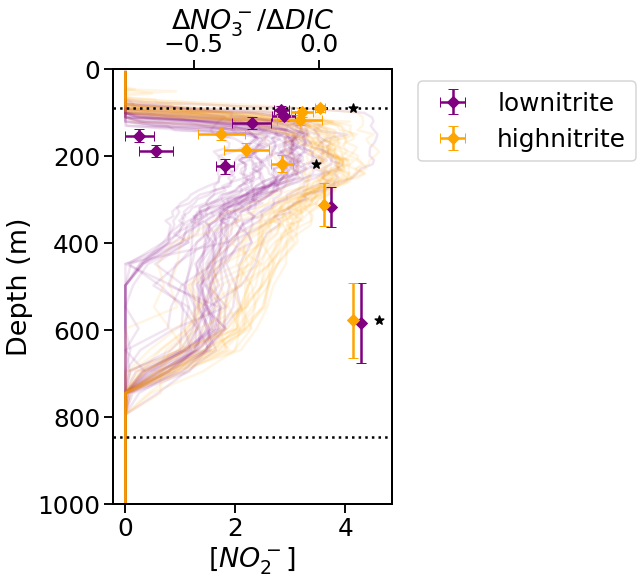

In [294]:
stationlistlow = stationdict["lownitrite"]
stationlisthigh = stationdict["highnitrite"]

chunk1 = "lownitrite"
chunk2 = "highnitrite"

fig, ax = plt.subplots(1,1, figsize = (5,8))
for s in stationlistlow:
    stationdata = data[data.Station == s].sort_values("Depth")
    if len(stationdata) > 0:
        ax.plot(np.array(stationdata.NO2), np.array(stationdata.Depth),
                color = "purple", label = None, alpha = 0.1)

for s in stationlisthigh:
    stationdata = data[data.Station == s].sort_values("Depth")
    if len(stationdata) > 0:
        ax.plot(np.array(stationdata.NO2), np.array(stationdata.Depth),
                color = "orange", label = None, alpha = 0.1)
ax.set_ylim([1000,0])
ax.set_xlabel(r"[$NO_2^-$]")

ax2 = ax.twiny()
ax2.errorbar(slopeslow.NstarvsDICslope, slopeslow.depth,
            xerr = slopeslow.NstarvsDICerr, yerr = slopeslow.deptherr, label = r"Low $NO_2^-$", color = "purple",
           marker = "D", linestyle = "none", capsize = 5)
ax2.errorbar(slopeshigh.NstarvsDICslope, slopeshigh.depth,
            xerr = slopeshigh.NstarvsDICerr, yerr = slopeshigh.deptherr, label = r"High $NO_2^-$", color = "orange",
           marker = "D", linestyle = "none", capsize = 5)

ax2.scatter(slopeshigh.NstarvsDICslope.iloc[idx_sig] + slopeslow.NstarvsDICerr.iloc[idx_sig] + 0.1,
            slopeshigh.depth.iloc[idx_sig], marker = "*", color = "k")


ax2.legend(bbox_to_anchor = (1.05, 1.0))
ax2.set_ylim([1000,0])
ax2.set_xlabel(r"$\delta*100 NO_3^-/\delta*100 DIC$")
ax.set_ylabel(r"Depth (m)")

ax2.axhline(upperinterfacedepth, color = "k", linestyle = ":")
ax2.axhline(lowerinterfacedepth, color = "k", linestyle = ":")

In [295]:
slope1 = slopeslow.iloc[layer].NstarvsDICslope
se1 = slopeslow.iloc[layer].NstarvsDICerr
n1 = slopeslow.iloc[layer].n
k1 = 2

slope2 = slopeshigh.iloc[layer].NstarvsDICslope
se2 = slopeshigh.iloc[layer].NstarvsDICerr
n2 = slopeshigh.iloc[layer].n
k2 = 2

# Test statistic
t_stat = (slope1 - slope2) / np.sqrt(se1**2 + se2**2)

# Degrees of freedom (Welch–Satterthwaite)
numerator = (se1**2 + se2**2)**2
denominator = (se1**4)/(n1 - k1) + (se2**4)/(n2 - k2)
df = numerator / denominator

# Two-tailed p-value
p = 2 * (1 - t.cdf(abs(t_stat), df))

print(f"t = {t_stat:.3f}, df = {df:.1f}, p = {p:.4f}")

t = 6.152, df = 301.3, p = 0.0000


In [296]:
from scipy.stats import ttest_ind, ttest_ind_from_stats

# Compute the descriptive statistics of a and b.
abar = slopeslow.iloc[layer].NstarvsDICslope
avar = slopeslow.iloc[layer].NstarvsDICerr #sample1.var(ddof=1)
na = slopeslow.iloc[layer].n
adof = na - 1

bbar = slopeshigh.iloc[layer].NstarvsDICslope
bvar = slopeshigh.iloc[layer].NstarvsDICerr #sample2.var(ddof=1)
nb = slopeshigh.iloc[layer].n
bdof = nb - 1

# Use scipy.stats.ttest_ind_from_stats.
t2, p2 = ttest_ind_from_stats(abar, avar * np.sqrt(na), na,
                              bbar, bvar * np.sqrt(nb), nb,
                              equal_var=False)
print("ttest_ind_from_stats: t = %g  p = %g" % (t2, p2))

ttest_ind_from_stats: t = 6.15172  p = 2.41967e-09


t = -2.985, df = 115.0, p = 0.0035
t = 1.830, df = 116.9, p = 0.0697
t = 5.193, df = 74.4, p = 0.0000
t = -39.230, df = 163.3, p = 0.0000
t = -5.428, df = 191.8, p = 0.0000
t = -13.912, df = 203.6, p = 0.0000
t = -20.449, df = 816.3, p = 0.0000
t = 8.882, df = 227.4, p = 0.0000


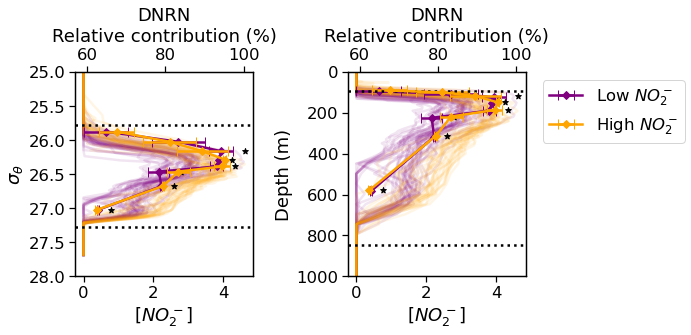

In [328]:
columndict = {"# DNRN":"DNRN",
        " Anammox":"anammox",
        " Denitrification":"denitrification",
        " Nitrite Oxidation":"nitrox",
        " CaCO3 Dissolution ":"caco3diss"}

chunklow = "lownitrite"
chunkhigh = "highnitrite"

param = "DNRN"
delta = 0.03

slopeslow = pd.read_excel(f"output/chunk{chunklow}/slopesDF.xlsx")
slopeshigh = pd.read_excel(f"output/chunk{chunkhigh}/slopesDF.xlsx")

pvals = np.ones(slopeslow.shape[0])
outputvals = np.ones((slopeslow.shape[0],4))

for layer in list(slopeslow.index):

    dflow = pd.read_csv(f"output/chunk{chunklow}/layer{layer}_coeff_iter.csv").rename(columns = columndict)
    dfhigh = pd.read_csv(f"output/chunk{chunkhigh}/layer{layer}_coeff_iter.csv").rename(columns = columndict)
    
    slope1 = dflow[param].mean()
    n1 = slopeslow.iloc[layer].n
    se1 = dflow[param].std() / np.sqrt(n1)
    k1 = 2
    
    slope2 = dfhigh[param].mean()
    n2 = slopeshigh.iloc[layer].n
    se2 = dfhigh[param].std() / np.sqrt(n2)
    k2 = 2
    
    # Test statistic
    t_stat = (slope1 - slope2) / np.sqrt(se1**2 + se2**2)
    
    # Degrees of freedom (Welch–Satterthwaite)
    numerator = (se1**2 + se2**2)**2
    denominator = (se1**4)/(n1 - k1) + (se2**4)/(n2 - k2)
    df = numerator / denominator
    
    # Two-tailed p-value
    p = 2 * (1 - t.cdf(abs(t_stat), df))
    
    pvals[layer] = p
    outputvals[layer,:] = np.array([slope1, dflow[param].std(), slope2, dfhigh[param].std()])
    
    print(f"t = {t_stat:.3f}, df = {df:.1f}, p = {p:.4f}")

idx_sig = np.where(pvals <= 0.001)

stationlistlow = stationdict["lownitrite"]
stationlisthigh = stationdict["highnitrite"]

chunklow = "lownitrite"
chunkhigh = "highnitrite"

fig, axes = plt.subplots(1,2, figsize = (10,5))

ax = axes[0]
for s in stationlistlow:
    stationdata = data[data.Station == s].sort_values("sigma0")
    if len(stationdata) > 0:
        ax.plot(np.array(stationdata.NO2), np.array(stationdata.sigma0),
                color = "purple", label = None, alpha = 0.1, zorder = 0)

for s in stationlisthigh:
    stationdata = data[data.Station == s].sort_values("sigma0")
    if len(stationdata) > 0:
        ax.plot(np.array(stationdata.NO2), np.array(stationdata.sigma0),
                color = "orange", label = None, alpha = 0.1, zorder = 0)

ax.set_ylim([28,25])
ax.set_ylabel(r"$\sigma_{\theta}$")
ax.set_xlabel(r"[$NO_2^-$]")

ax2 = ax.twiny()
ax2.errorbar(outputvals[:,0]*100, slopeslow.sigma0,
            xerr = outputvals[:,1]*100, label = r"Low $NO_2^-$", color = "purple",
           marker = "D", capsize = 5, zorder = 1)
ax2.errorbar(outputvals[:,2]*100, slopeshigh.sigma0,
            xerr = outputvals[:,3]*100, label = r"High $NO_2^-$", color = "orange",
           marker = "D", capsize = 5, zorder = 2)

ax2.scatter(outputvals[idx_sig,0]*100 + outputvals[idx_sig,1]*100 + delta*100,
            slopeshigh.sigma0.iloc[idx_sig], marker = "*", color = "k")

#ax2.legend(bbox_to_anchor = (1.05, 1.0), loc = "upper left")
ax2.set_ylim([28,25])

ax2.axhline(upperinterfacesigma, color = "k", linestyle = ":")
ax2.axhline(lowerinterfacesigma, color = "k", linestyle = ":")
ax2.set_title(f"{param}\nRelative contribution (%)")

ax = axes[1]
for s in stationlistlow:
    stationdata = data[data.Station == s].sort_values("Depth")
    if len(stationdata) > 0:
        ax.plot(np.array(stationdata.NO2), np.array(stationdata.Depth),
                color = "purple", label = None, alpha = 0.1, zorder = 0)

for s in stationlisthigh:
    stationdata = data[data.Station == s].sort_values("Depth")
    if len(stationdata) > 0:
        ax.plot(np.array(stationdata.NO2), np.array(stationdata.Depth),
                color = "orange", label = None, alpha = 0.1, zorder = 0)

ax.set_ylim([1000,0])
ax.set_ylabel(r"Depth (m)")
ax.set_xlabel(r"[$NO_2^-$]")

ax2 = ax.twiny()
ax2.errorbar(outputvals[:,0]*100, slopeslow.depth,
            xerr = outputvals[:,1]*100, label = r"Low $NO_2^-$", color = "purple",
           marker = "D", capsize = 5, zorder = 1)
ax2.errorbar(outputvals[:,2]*100, slopeshigh.depth,
            xerr = outputvals[:,3]*100, label = r"High $NO_2^-$", color = "orange",
           marker = "D", capsize = 5, zorder = 2)

ax2.scatter(outputvals[idx_sig,0]*100 + outputvals[idx_sig,1]*100 + delta*100,
            slopeshigh.depth.iloc[idx_sig], marker = "*", color = "k")

ax2.legend(bbox_to_anchor = (1.05, 1.0), loc = "upper left")
ax2.set_ylim([1000,0])

ax2.axhline(upperinterfacedepth, color = "k", linestyle = ":")
ax2.axhline(lowerinterfacedepth, color = "k", linestyle = ":")
ax2.set_title(f"{param}\nRelative contribution (%)")

plt.tight_layout()
plt.savefig("figures/DNRNprofiles.pdf", bbox_inches = "tight")

t = 7.088, df = 66.9, p = 0.0000
t = 2.821, df = 103.9, p = 0.0057
t = 16.170, df = 132.8, p = 0.0000
t = 38.846, df = 163.3, p = 0.0000
t = 35.818, df = 166.2, p = 0.0000
t = 11.628, df = 245.5, p = 0.0000
t = nan, df = nan, p = nan
t = nan, df = nan, p = nan


/var/folders/gd/mzwd8ycd1q5d_pmld48bt7c80000gn/T/ipykernel_1230/3450156761.py:35: RuntimeWarning: invalid value encountered in scalar divide
  t_stat = (slope1 - slope2) / np.sqrt(se1**2 + se2**2)
/var/folders/gd/mzwd8ycd1q5d_pmld48bt7c80000gn/T/ipykernel_1230/3450156761.py:40: RuntimeWarning: invalid value encountered in scalar divide
  df = numerator / denominator
/var/folders/gd/mzwd8ycd1q5d_pmld48bt7c80000gn/T/ipykernel_1230/3450156761.py:35: RuntimeWarning: invalid value encountered in scalar divide
  t_stat = (slope1 - slope2) / np.sqrt(se1**2 + se2**2)
/var/folders/gd/mzwd8ycd1q5d_pmld48bt7c80000gn/T/ipykernel_1230/3450156761.py:40: RuntimeWarning: invalid value encountered in scalar divide
  df = numerator / denominator


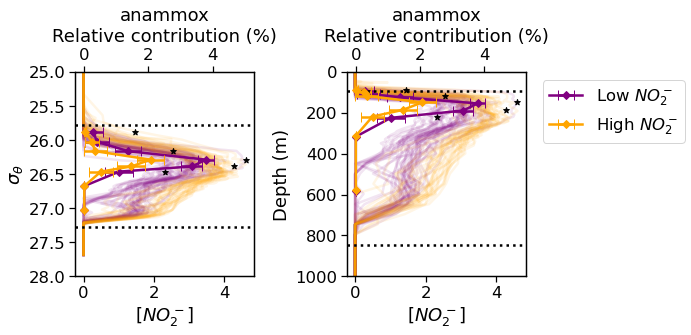

In [332]:
columndict = {"# DNRN":"DNRN",
        " Anammox":"anammox",
        " Denitrification":"denitrification",
        " Nitrite Oxidation":"nitrox",
        " CaCO3 Dissolution ":"caco3diss"}

chunklow = "lownitrite"
chunkhigh = "highnitrite"

param = "anammox"
delta = 0.01

slopeslow = pd.read_excel(f"output/chunk{chunklow}/slopesDF.xlsx")
slopeshigh = pd.read_excel(f"output/chunk{chunkhigh}/slopesDF.xlsx")

pvals = np.ones(slopeslow.shape[0])
outputvals = np.ones((slopeslow.shape[0],4))

for layer in list(slopeslow.index):

    dflow = pd.read_csv(f"output/chunk{chunklow}/layer{layer}_coeff_iter.csv").rename(columns = columndict)
    dfhigh = pd.read_csv(f"output/chunk{chunkhigh}/layer{layer}_coeff_iter.csv").rename(columns = columndict)
    
    slope1 = dflow[param].mean()
    n1 = slopeslow.iloc[layer].n
    se1 = dflow[param].std() / np.sqrt(n1)
    k1 = 2
    
    slope2 = dfhigh[param].mean()
    n2 = slopeshigh.iloc[layer].n
    se2 = dfhigh[param].std() / np.sqrt(n2)
    k2 = 2
    
    # Test statistic
    t_stat = (slope1 - slope2) / np.sqrt(se1**2 + se2**2)
    
    # Degrees of freedom (Welch–Satterthwaite)
    numerator = (se1**2 + se2**2)**2
    denominator = (se1**4)/(n1 - k1) + (se2**4)/(n2 - k2)
    df = numerator / denominator
    
    # Two-tailed p-value
    p = 2 * (1 - t.cdf(abs(t_stat), df))
    
    pvals[layer] = p
    outputvals[layer,:] = np.array([slope1, dflow[param].std(), slope2, dfhigh[param].std()])
    
    print(f"t = {t_stat:.3f}, df = {df:.1f}, p = {p:.4f}")

idx_sig = np.where(pvals <= 0.001)

stationlistlow = stationdict["lownitrite"]
stationlisthigh = stationdict["highnitrite"]

chunklow = "lownitrite"
chunkhigh = "highnitrite"

fig, axes = plt.subplots(1,2, figsize = (10,5))

ax = axes[0]
for s in stationlistlow:
    stationdata = data[data.Station == s].sort_values("sigma0")
    if len(stationdata) > 0:
        ax.plot(np.array(stationdata.NO2), np.array(stationdata.sigma0),
                color = "purple", label = None, alpha = 0.1, zorder = 0)

for s in stationlisthigh:
    stationdata = data[data.Station == s].sort_values("sigma0")
    if len(stationdata) > 0:
        ax.plot(np.array(stationdata.NO2), np.array(stationdata.sigma0),
                color = "orange", label = None, alpha = 0.1, zorder = 0)

ax.set_ylim([28,25])
ax.set_ylabel(r"$\sigma_{\theta}$")
ax.set_xlabel(r"[$NO_2^-$]")

ax2 = ax.twiny()
ax2.errorbar(outputvals[:,0]*100, slopeslow.sigma0,
            xerr = outputvals[:,1]*100, label = r"Low $NO_2^-$", color = "purple",
           marker = "D", capsize = 5, zorder = 1)
ax2.errorbar(outputvals[:,2]*100, slopeshigh.sigma0,
            xerr = outputvals[:,3]*100, label = r"High $NO_2^-$", color = "orange",
           marker = "D", capsize = 5, zorder = 2)

ax2.scatter(outputvals[idx_sig,0]*100 + outputvals[idx_sig,1]*100 + delta*100,
            slopeshigh.sigma0.iloc[idx_sig], marker = "*", color = "k")

#ax2.legend(bbox_to_anchor = (1.05, 1.0), loc = "upper left")
ax2.set_ylim([28,25])

ax2.axhline(upperinterfacesigma, color = "k", linestyle = ":")
ax2.axhline(lowerinterfacesigma, color = "k", linestyle = ":")
ax2.set_title(f"{param}\nRelative contribution (%)")

ax = axes[1]
for s in stationlistlow:
    stationdata = data[data.Station == s].sort_values("Depth")
    if len(stationdata) > 0:
        ax.plot(np.array(stationdata.NO2), np.array(stationdata.Depth),
                color = "purple", label = None, alpha = 0.1, zorder = 0)

for s in stationlisthigh:
    stationdata = data[data.Station == s].sort_values("Depth")
    if len(stationdata) > 0:
        ax.plot(np.array(stationdata.NO2), np.array(stationdata.Depth),
                color = "orange", label = None, alpha = 0.1, zorder = 0)

ax.set_ylim([1000,0])
ax.set_ylabel(r"Depth (m)")
ax.set_xlabel(r"[$NO_2^-$]")

ax2 = ax.twiny()
ax2.errorbar(outputvals[:,0]*100, slopeslow.depth,
            xerr = outputvals[:,1]*100, label = r"Low $NO_2^-$", color = "purple",
           marker = "D", capsize = 5, zorder = 1)
ax2.errorbar(outputvals[:,2]*100, slopeshigh.depth,
            xerr = outputvals[:,3]*100, label = r"High $NO_2^-$", color = "orange",
           marker = "D", capsize = 5, zorder = 2)

ax2.scatter(outputvals[idx_sig,0]*100 + outputvals[idx_sig,1]*100 + delta*100,
            slopeshigh.depth.iloc[idx_sig], marker = "*", color = "k")

ax2.legend(bbox_to_anchor = (1.05, 1.0), loc = "upper left")
ax2.set_ylim([1000,0])

ax2.axhline(upperinterfacedepth, color = "k", linestyle = ":")
ax2.axhline(lowerinterfacedepth, color = "k", linestyle = ":")
ax2.set_title(f"{param}\nRelative contribution (%)")

plt.tight_layout()
plt.savefig(f"figures/{param}profiles.pdf", bbox_inches = "tight")

t = 17.772, df = 66.0, p = 0.0000
t = 6.189, df = 86.4, p = 0.0000
t = -0.311, df = 127.5, p = 0.7565
t = nan, df = nan, p = nan
t = -0.048, df = 193.1, p = 0.9615
t = 17.199, df = 259.9, p = 0.0000
t = nan, df = nan, p = nan
t = nan, df = nan, p = nan


/var/folders/gd/mzwd8ycd1q5d_pmld48bt7c80000gn/T/ipykernel_1230/3173826998.py:35: RuntimeWarning: invalid value encountered in scalar divide
  t_stat = (slope1 - slope2) / np.sqrt(se1**2 + se2**2)
/var/folders/gd/mzwd8ycd1q5d_pmld48bt7c80000gn/T/ipykernel_1230/3173826998.py:40: RuntimeWarning: invalid value encountered in scalar divide
  df = numerator / denominator
/var/folders/gd/mzwd8ycd1q5d_pmld48bt7c80000gn/T/ipykernel_1230/3173826998.py:35: RuntimeWarning: invalid value encountered in scalar divide
  t_stat = (slope1 - slope2) / np.sqrt(se1**2 + se2**2)
/var/folders/gd/mzwd8ycd1q5d_pmld48bt7c80000gn/T/ipykernel_1230/3173826998.py:40: RuntimeWarning: invalid value encountered in scalar divide
  df = numerator / denominator
/var/folders/gd/mzwd8ycd1q5d_pmld48bt7c80000gn/T/ipykernel_1230/3173826998.py:35: RuntimeWarning: invalid value encountered in scalar divide
  t_stat = (slope1 - slope2) / np.sqrt(se1**2 + se2**2)
/var/folders/gd/mzwd8ycd1q5d_pmld48bt7c80000gn/T/ipykernel_1230/3

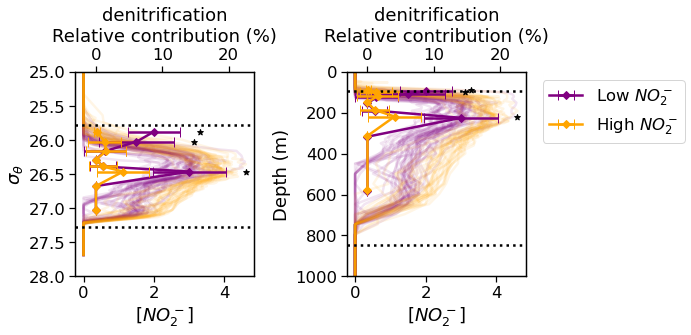

In [336]:
columndict = {"# DNRN":"DNRN",
        " Anammox":"anammox",
        " Denitrification":"denitrification",
        " Nitrite Oxidation":"nitrox",
        " CaCO3 Dissolution ":"caco3diss"}

chunklow = "lownitrite"
chunkhigh = "highnitrite"

param = "denitrification"
delta = 0.03

slopeslow = pd.read_excel(f"output/chunk{chunklow}/slopesDF.xlsx")
slopeshigh = pd.read_excel(f"output/chunk{chunkhigh}/slopesDF.xlsx")

pvals2 = np.ones(slopeslow.shape[0])
outputvals = np.ones((slopeslow.shape[0],4))

for layer in list(slopeslow.index):

    dflow = pd.read_csv(f"output/chunk{chunklow}/layer{layer}_coeff_iter.csv").rename(columns = columndict)
    dfhigh = pd.read_csv(f"output/chunk{chunkhigh}/layer{layer}_coeff_iter.csv").rename(columns = columndict)
    
    slope1 = dflow[param].mean()
    n1 = slopeslow.iloc[layer].n
    se1 = dflow[param].std() / np.sqrt(n1)
    k1 = 2
    
    slope2 = dfhigh[param].mean()
    n2 = slopeshigh.iloc[layer].n
    se2 = dfhigh[param].std() / np.sqrt(n2)
    k2 = 2
    
    # Test statistic
    t_stat = (slope1 - slope2) / np.sqrt(se1**2 + se2**2)
    
    # Degrees of freedom (Welch–Satterthwaite)
    numerator = (se1**2 + se2**2)**2
    denominator = (se1**4)/(n1 - k1) + (se2**4)/(n2 - k2)
    df = numerator / denominator
    
    # Two-tailed p-value
    p = 2 * (1 - t.cdf(abs(t_stat), df))
    
    pvals2[layer] = p
    outputvals[layer,:] = np.array([slope1, dflow[param].std(), slope2, dfhigh[param].std()])
    
    print(f"t = {t_stat:.3f}, df = {df:.1f}, p = {p:.4f}")

idx_sig2 = np.where(pvals2 <= 0.001)

stationlistlow = stationdict["lownitrite"]
stationlisthigh = stationdict["highnitrite"]

chunklow = "lownitrite"
chunkhigh = "highnitrite"

fig, axes = plt.subplots(1,2, figsize = (10,5))

ax = axes[0]
for s in stationlistlow:
    stationdata = data[data.Station == s].sort_values("sigma0")
    if len(stationdata) > 0:
        ax.plot(np.array(stationdata.NO2), np.array(stationdata.sigma0),
                color = "purple", label = None, alpha = 0.1, zorder = 0)

for s in stationlisthigh:
    stationdata = data[data.Station == s].sort_values("sigma0")
    if len(stationdata) > 0:
        ax.plot(np.array(stationdata.NO2), np.array(stationdata.sigma0),
                color = "orange", label = None, alpha = 0.1, zorder = 0)

ax.set_ylim([28,25])
ax.set_ylabel(r"$\sigma_{\theta}$")
ax.set_xlabel(r"[$NO_2^-$]")

ax2 = ax.twiny()
ax2.errorbar(outputvals[:,0]*100, slopeslow.sigma0,
            xerr = outputvals[:,1]*100, label = r"Low $NO_2^-$", color = "purple",
           marker = "D", capsize = 5, zorder = 1)
ax2.errorbar(outputvals[:,2]*100, slopeshigh.sigma0,
            xerr = outputvals[:,3]*100, label = r"High $NO_2^-$", color = "orange",
           marker = "D", capsize = 5, zorder = 2)

ax2.scatter(outputvals[idx_sig2,0]*100 + outputvals[idx_sig2,1]*100 + delta*100,
            slopeshigh.sigma0.iloc[idx_sig2], marker = "*", color = "k")

#ax2.legend(bbox_to_anchor = (1.05, 1.0), loc = "upper left")
ax2.set_ylim([28,25])

ax2.axhline(upperinterfacesigma, color = "k", linestyle = ":")
ax2.axhline(lowerinterfacesigma, color = "k", linestyle = ":")
ax2.set_title(f"{param}\nRelative contribution (%)")

ax = axes[1]
for s in stationlistlow:
    stationdata = data[data.Station == s].sort_values("Depth")
    if len(stationdata) > 0:
        ax.plot(np.array(stationdata.NO2), np.array(stationdata.Depth),
                color = "purple", label = None, alpha = 0.1, zorder = 0)

for s in stationlisthigh:
    stationdata = data[data.Station == s].sort_values("Depth")
    if len(stationdata) > 0:
        ax.plot(np.array(stationdata.NO2), np.array(stationdata.Depth),
                color = "orange", label = None, alpha = 0.1, zorder = 0)

ax.set_ylim([1000,0])
ax.set_ylabel(r"Depth (m)")
ax.set_xlabel(r"[$NO_2^-$]")

ax2 = ax.twiny()
ax2.errorbar(outputvals[:,0]*100, slopeslow.depth,
            xerr = outputvals[:,1]*100, label = r"Low $NO_2^-$", color = "purple",
           marker = "D", capsize = 5, zorder = 1)
ax2.errorbar(outputvals[:,2]*100, slopeshigh.depth,
            xerr = outputvals[:,3]*100, label = r"High $NO_2^-$", color = "orange",
           marker = "D", capsize = 5, zorder = 2)

ax2.scatter(outputvals[idx_sig2,0]*100 + outputvals[idx_sig2,1]*100 + delta*100,
            slopeshigh.depth.iloc[idx_sig2], marker = "*", color = "k")

ax2.legend(bbox_to_anchor = (1.05, 1.0), loc = "upper left")
ax2.set_ylim([1000,0])

ax2.axhline(upperinterfacedepth, color = "k", linestyle = ":")
ax2.axhline(lowerinterfacedepth, color = "k", linestyle = ":")
ax2.set_title(f"{param}\nRelative contribution (%)")

plt.tight_layout()
plt.savefig(f"figures/{param}profiles.pdf", bbox_inches = "tight")

t = -8.584, df = 114.6, p = 0.0000
t = -0.335, df = 117.9, p = 0.7383
t = -0.685, df = 83.1, p = 0.4956
t = -26.034, df = 175.7, p = 0.0000
t = -23.210, df = 168.2, p = 0.0000
t = -30.658, df = 192.3, p = 0.0000
t = 60.364, df = 830.3, p = 0.0000
t = -6.061, df = 244.7, p = 0.0000


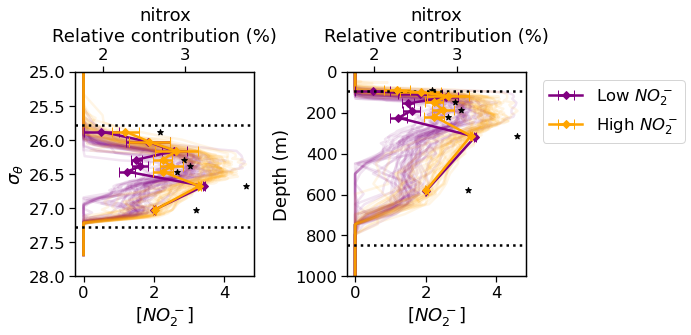

In [346]:
columndict = {"# DNRN":"DNRN",
        " Anammox":"anammox",
        " Denitrification":"denitrification",
        " Nitrite Oxidation":"nitrox",
        " CaCO3 Dissolution ":"caco3diss"}

chunklow = "lownitrite"
chunkhigh = "highnitrite"

param = "nitrox"
delta = 0.005

slopeslow = pd.read_excel(f"output/chunk{chunklow}/slopesDF.xlsx")
slopeshigh = pd.read_excel(f"output/chunk{chunkhigh}/slopesDF.xlsx")

pvals = np.ones(slopeslow.shape[0])
outputvals = np.ones((slopeslow.shape[0],4))

for layer in list(slopeslow.index):

    dflow = pd.read_csv(f"output/chunk{chunklow}/layer{layer}_coeff_iter.csv").rename(columns = columndict)
    dfhigh = pd.read_csv(f"output/chunk{chunkhigh}/layer{layer}_coeff_iter.csv").rename(columns = columndict)
    
    slope1 = dflow[param].mean()
    n1 = slopeslow.iloc[layer].n
    se1 = dflow[param].std() / np.sqrt(n1)
    k1 = 2
    
    slope2 = dfhigh[param].mean()
    n2 = slopeshigh.iloc[layer].n
    se2 = dfhigh[param].std() / np.sqrt(n2)
    k2 = 2
    
    # Test statistic
    t_stat = (slope1 - slope2) / np.sqrt(se1**2 + se2**2)
    
    # Degrees of freedom (Welch–Satterthwaite)
    numerator = (se1**2 + se2**2)**2
    denominator = (se1**4)/(n1 - k1) + (se2**4)/(n2 - k2)
    df = numerator / denominator
    
    # Two-tailed p-value
    p = 2 * (1 - t.cdf(abs(t_stat), df))
    
    pvals[layer] = p
    outputvals[layer,:] = np.array([slope1, dflow[param].std(), slope2, dfhigh[param].std()])
    
    print(f"t = {t_stat:.3f}, df = {df:.1f}, p = {p:.4f}")

idx_sig = np.where(pvals <= 0.001)

stationlistlow = stationdict["lownitrite"]
stationlisthigh = stationdict["highnitrite"]

chunklow = "lownitrite"
chunkhigh = "highnitrite"

fig, axes = plt.subplots(1,2, figsize = (10,5))

ax = axes[0]
for s in stationlistlow:
    stationdata = data[data.Station == s].sort_values("sigma0")
    if len(stationdata) > 0:
        ax.plot(np.array(stationdata.NO2), np.array(stationdata.sigma0),
                color = "purple", label = None, alpha = 0.1, zorder = 0)

for s in stationlisthigh:
    stationdata = data[data.Station == s].sort_values("sigma0")
    if len(stationdata) > 0:
        ax.plot(np.array(stationdata.NO2), np.array(stationdata.sigma0),
                color = "orange", label = None, alpha = 0.1, zorder = 0)

ax.set_ylim([28,25])
ax.set_ylabel(r"$\sigma_{\theta}$")
ax.set_xlabel(r"[$NO_2^-$]")

ax2 = ax.twiny()
ax2.errorbar(outputvals[:,0]*100, slopeslow.sigma0,
            xerr = outputvals[:,1]*100, label = r"Low $NO_2^-$", color = "purple",
           marker = "D", capsize = 5, zorder = 1)
ax2.errorbar(outputvals[:,2]*100, slopeshigh.sigma0,
            xerr = outputvals[:,3]*100, label = r"High $NO_2^-$", color = "orange",
           marker = "D", capsize = 5, zorder = 2)

ax2.scatter(outputvals[idx_sig,0]*100 + outputvals[idx_sig,1]*100 + delta*100,
            slopeshigh.sigma0.iloc[idx_sig], marker = "*", color = "k")

#ax2.legend(bbox_to_anchor = (1.05, 1.0), loc = "upper left")
ax2.set_ylim([28,25])

ax2.axhline(upperinterfacesigma, color = "k", linestyle = ":")
ax2.axhline(lowerinterfacesigma, color = "k", linestyle = ":")
ax2.set_title(f"{param}\nRelative contribution (%)")

ax = axes[1]
for s in stationlistlow:
    stationdata = data[data.Station == s].sort_values("Depth")
    if len(stationdata) > 0:
        ax.plot(np.array(stationdata.NO2), np.array(stationdata.Depth),
                color = "purple", label = None, alpha = 0.1, zorder = 0)

for s in stationlisthigh:
    stationdata = data[data.Station == s].sort_values("Depth")
    if len(stationdata) > 0:
        ax.plot(np.array(stationdata.NO2), np.array(stationdata.Depth),
                color = "orange", label = None, alpha = 0.1, zorder = 0)

ax.set_ylim([1000,0])
ax.set_ylabel(r"Depth (m)")
ax.set_xlabel(r"[$NO_2^-$]")

ax2 = ax.twiny()
ax2.errorbar(outputvals[:,0]*100, slopeslow.depth,
            xerr = outputvals[:,1]*100, label = r"Low $NO_2^-$", color = "purple",
           marker = "D", capsize = 5, zorder = 1)
ax2.errorbar(outputvals[:,2]*100, slopeshigh.depth,
            xerr = outputvals[:,3]*100, label = r"High $NO_2^-$", color = "orange",
           marker = "D", capsize = 5, zorder = 2)

ax2.scatter(outputvals[idx_sig,0]*100 + outputvals[idx_sig,1]*100 + delta*100,
            slopeshigh.depth.iloc[idx_sig], marker = "*", color = "k")

ax2.legend(bbox_to_anchor = (1.05, 1.0), loc = "upper left")
ax2.set_ylim([1000,0])

ax2.axhline(upperinterfacedepth, color = "k", linestyle = ":")
ax2.axhline(lowerinterfacedepth, color = "k", linestyle = ":")
ax2.set_title(f"{param}\nRelative contribution (%)")

plt.tight_layout()
plt.savefig(f"figures/{param}profiles.pdf", bbox_inches = "tight")

t = -15.757, df = 51.5, p = 0.0000
t = -7.699, df = 56.4, p = 0.0000
t = 0.040, df = 58.2, p = 0.9684
t = 191.970, df = 145.0, p = 0.0000
t = 11.508, df = 98.9, p = 0.0000
t = -24.106, df = 103.8, p = 0.0000
t = nan, df = nan, p = nan
t = nan, df = nan, p = nan
t = -2.104, df = 51.9, p = 0.0402
t = -3.300, df = 56.9, p = 0.0017
t = -2.970, df = 58.6, p = 0.0043
t = 51.842, df = 110.0, p = 0.0000
t = 1.715, df = 103.0, p = 0.0894
t = -9.155, df = 104.7, p = 0.0000
t = nan, df = nan, p = nan
t = nan, df = nan, p = nan


/var/folders/gd/mzwd8ycd1q5d_pmld48bt7c80000gn/T/ipykernel_1230/1502249991.py:41: RuntimeWarning: invalid value encountered in scalar divide
  t_stat = (slope1 - slope2) / np.sqrt(se1**2 + se2**2)
/var/folders/gd/mzwd8ycd1q5d_pmld48bt7c80000gn/T/ipykernel_1230/1502249991.py:46: RuntimeWarning: invalid value encountered in scalar divide
  df = numerator / denominator
/var/folders/gd/mzwd8ycd1q5d_pmld48bt7c80000gn/T/ipykernel_1230/1502249991.py:41: RuntimeWarning: invalid value encountered in scalar divide
  t_stat = (slope1 - slope2) / np.sqrt(se1**2 + se2**2)
/var/folders/gd/mzwd8ycd1q5d_pmld48bt7c80000gn/T/ipykernel_1230/1502249991.py:46: RuntimeWarning: invalid value encountered in scalar divide
  df = numerator / denominator
/var/folders/gd/mzwd8ycd1q5d_pmld48bt7c80000gn/T/ipykernel_1230/1502249991.py:106: RuntimeWarning: invalid value encountered in scalar divide
  t_stat = (slope1 - slope2) / np.sqrt(se1**2 + se2**2)
/var/folders/gd/mzwd8ycd1q5d_pmld48bt7c80000gn/T/ipykernel_1230/

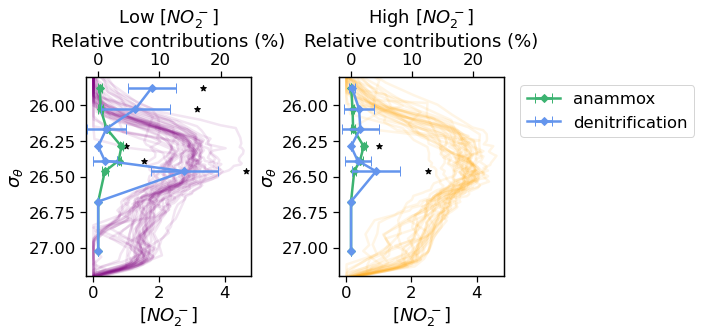

In [357]:
columndict = {"# DNRN":"DNRN",
        " Anammox":"anammox",
        " Denitrification":"denitrification",
        " Nitrite Oxidation":"nitrox",
        " CaCO3 Dissolution ":"caco3diss"}

chunklow = "lownitrite"
chunkhigh = "highnitrite"

stationlistlow = stationdict["lownitrite"]
stationlisthigh = stationdict["highnitrite"]

param1 = "anammox"
param2 = "denitrification"
delta = 0.045

fig, axes = plt.subplots(1,2, figsize = (10,5))

slopeslow = pd.read_excel(f"output/chunk{chunklow}/slopesDF.xlsx")
slopeshigh = pd.read_excel(f"output/chunk{chunkhigh}/slopesDF.xlsx")

pvals = np.ones(slopeslow.shape[0])
outputvals = np.ones((slopeslow.shape[0],4))

for layer in list(slopeslow.index):

    dflow = pd.read_csv(f"output/chunk{chunklow}/layer{layer}_coeff_iter.csv").rename(columns = columndict)
    dfhigh = pd.read_csv(f"output/chunk{chunkhigh}/layer{layer}_coeff_iter.csv").rename(columns = columndict)
    
    slope1 = dflow[param1].mean()
    n1 = slopeslow.iloc[layer].n
    se1 = dflow[param1].std() / np.sqrt(n1)
    k1 = 2
    
    slope2 = dflow[param2].mean()
    n2 = slopeshigh.iloc[layer].n
    se2 = dflow[param2].std() / np.sqrt(n2)
    k2 = 2
    
    # Test statistic
    t_stat = (slope1 - slope2) / np.sqrt(se1**2 + se2**2)
    
    # Degrees of freedom (Welch–Satterthwaite)
    numerator = (se1**2 + se2**2)**2
    denominator = (se1**4)/(n1 - k1) + (se2**4)/(n2 - k2)
    df = numerator / denominator
    
    # Two-tailed p-value
    p = 2 * (1 - t.cdf(abs(t_stat), df))
    
    pvals[layer] = p
    outputvals[layer,:] = np.array([slope1, dflow[param1].std(), slope2, dflow[param2].std()])
    
    print(f"t = {t_stat:.3f}, df = {df:.1f}, p = {p:.4f}")

idx_sig = np.where(pvals <= 0.001)

ax = axes[0]
for s in stationlistlow:
    stationdata = data[data.Station == s].sort_values("sigma0")
    if len(stationdata) > 0:
        ax.plot(np.array(stationdata.NO2), np.array(stationdata.sigma0),
                color = "purple", label = None, alpha = 0.1, zorder = 0)

ax.set_ylim([28,25])
ax.set_ylabel(r"$\sigma_{\theta}$")
ax.set_xlabel(r"[$NO_2^-$]")
ax.set_title("Low [$NO_2^-$]\nRelative contributions (%)")

ax2 = ax.twiny()
ax2.errorbar(outputvals[:,0]*100, slopeslow.sigma0,
            xerr = outputvals[:,1]*100, label = param1, color = "mediumseagreen",
           marker = "D", capsize = 5, zorder = 1)
ax2.errorbar(outputvals[:,2]*100, slopeshigh.sigma0,
            xerr = outputvals[:,3]*100, label = param2, color = "cornflowerblue",
           marker = "D", capsize = 5, zorder = 2)

ax2.scatter(outputvals[idx_sig,2]*100 + outputvals[idx_sig,3]*100 + delta*100,
            slopeshigh.sigma0.iloc[idx_sig], marker = "*", color = "k")

#ax2.legend(bbox_to_anchor = (1.05, 1.0), loc = "upper left")
ax2.set_ylim([27.2,25.8])
ax2.set_xlim([-0.02*100, 0.25*100])

ax2.axhline(upperinterfacesigma, color = "k", linestyle = ":")
ax2.axhline(lowerinterfacesigma, color = "k", linestyle = ":")

pvals = np.ones(slopeslow.shape[0])
outputvals = np.ones((slopeslow.shape[0],4))

for layer in list(slopeshigh.index):

    dfhigh = pd.read_csv(f"output/chunk{chunkhigh}/layer{layer}_coeff_iter.csv").rename(columns = columndict)
    
    slope1 = dfhigh[param1].mean()
    n1 = slopeshigh.iloc[layer].n
    se1 = dfhigh[param1].std() / np.sqrt(n1)
    k1 = 2
    
    slope2 = dfhigh[param2].mean()
    n2 = slopeshigh.iloc[layer].n
    se2 = dfhigh[param2].std() / np.sqrt(n2)
    k2 = 2
    
    # Test statistic
    t_stat = (slope1 - slope2) / np.sqrt(se1**2 + se2**2)
    
    # Degrees of freedom (Welch–Satterthwaite)
    numerator = (se1**2 + se2**2)**2
    denominator = (se1**4)/(n1 - k1) + (se2**4)/(n2 - k2)
    df = numerator / denominator
    
    # Two-tailed p-value
    p = 2 * (1 - t.cdf(abs(t_stat), df))
    
    pvals[layer] = p
    outputvals[layer,:] = np.array([slope1, dfhigh[param1].std(), slope2, dfhigh[param2].std()])
    
    print(f"t = {t_stat:.3f}, df = {df:.1f}, p = {p:.4f}")

idx_sig = np.where(pvals <= 0.001)

ax = axes[1]
for s in stationlisthigh:
    stationdata = data[data.Station == s].sort_values("sigma0")
    if len(stationdata) > 0:
        ax.plot(np.array(stationdata.NO2), np.array(stationdata.sigma0),
                color = "orange", label = None, alpha = 0.1, zorder = 0)

ax.set_ylim([28,25])
ax.set_ylabel(r"$\sigma_{\theta}$")
ax.set_xlabel(r"[$NO_2^-$]")
ax.set_title("High [$NO_2^-$]\nRelative contributions (%)")

ax2 = ax.twiny()
ax2.errorbar(outputvals[:,0]*100, slopeslow.sigma0,
            xerr = outputvals[:,1]*100, label = param1, color = "mediumseagreen",
           marker = "D", capsize = 5, zorder = 1)
ax2.errorbar(outputvals[:,2]*100, slopeshigh.sigma0,
            xerr = outputvals[:,3]*100, label = param2, color = "cornflowerblue",
           marker = "D", capsize = 5, zorder = 2)
ax2.scatter(outputvals[idx_sig,2]*100 + outputvals[idx_sig,3]*100 + delta*100,
            slopeshigh.sigma0.iloc[idx_sig], marker = "*", color = "k")

ax2.legend(bbox_to_anchor = (1.05, 1.0), loc = "upper left")
ax2.set_ylim([27.2,25.8])
ax2.set_xlim([-0.02*100, 0.25*100])

ax2.axhline(upperinterfacesigma, color = "k", linestyle = ":")
ax2.axhline(lowerinterfacesigma, color = "k", linestyle = ":")

plt.tight_layout()
plt.savefig(f"figures/anammoxdenitprofiles.pdf", bbox_inches = "tight")

In [352]:
idx_sig

(array([], dtype=int64),)

In [207]:
layer = 2

df1 = pd.read_csv(f"output/chunk{chunk1}/layer{layer}_coeff_iter.csv").rename(columns = columndict)
df2 = pd.read_csv(f"output/chunk{chunk2}/layer{layer}_coeff_iter.csv").rename(columns = columndict)

slope1 = df1[param].mean()
n1 = slopeslow.iloc[layer].n
se1 = df1[param].std() / np.sqrt(n1)
k1 = 2

slope2 = df2[param].mean()
n2 = slopeshigh.iloc[layer].n
se2 = df2[param].std() / np.sqrt(n2)
k2 = 2

# Test statistic
t_stat = (slope1 - slope2) / np.sqrt(se1**2 + se2**2)

# Degrees of freedom (Welch–Satterthwaite)
numerator = (se1**2 + se2**2)**2
denominator = (se1**4)/(n1 - k1) + (se2**4)/(n2 - k2)
df = numerator / denominator

# Two-tailed p-value
p = 2 * (1 - t.cdf(abs(t_stat), df))

print(f"t = {t_stat:.3f}, df = {df:.1f}, p = {p:.4f}")

t = 5.365, df = 73.6, p = 0.0000


chunklownitrite layer 2 stdev = 0.03018205451898237
chunkhighnitrite layer 2 stdev = 0.06545210094601761


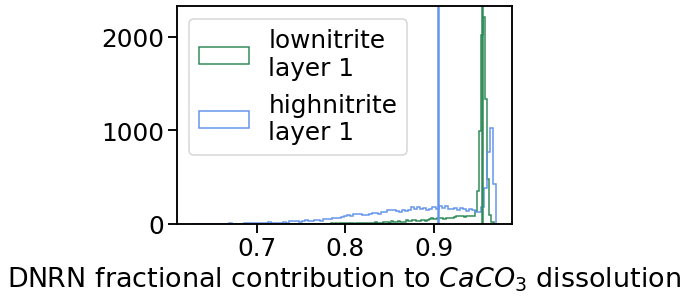

In [208]:
df1 = pd.read_csv(f"output/chunk{chunk1}/layer{layer}_coeff_iter.csv").rename(columns = columndict)
df2 = pd.read_csv(f"output/chunk{chunk2}/layer{layer}_coeff_iter.csv").rename(columns = columndict)

arr1 = np.array(df1[param])
arr2 = np.array(df2[param])

print(f"chunk{chunk1} layer {layer} stdev = {np.std(arr1)}")
print(f"chunk{chunk2} layer {layer} stdev = {np.std(arr2)}")

fig, ax = plt.subplots()
ax.hist(arr1, histtype = "step", bins = 100, label = label1, color = "seagreen")
ax.hist(arr2, histtype = "step", bins = 100, label = label2, color = "cornflowerblue")
ax.axvline(np.median(arr1), color = "seagreen")
ax.axvline(np.median(arr2), color = "cornflowerblue")
ax.set_xlabel(f"{param} fractional contribution to $CaCO_3$ dissolution")
ax.legend()

In [209]:
from scipy.stats import ttest_ind, ttest_ind_from_stats

# Compute the descriptive statistics of a and b.
abar = df1[param].mean()
astd = df1[param].std()
na = slopeslow.iloc[layer].n
adof = na - 1

bbar = df2[param].mean()
bstd = df2[param].std()
nb = slopeshigh.iloc[layer].n
bdof = nb - 1

# Use scipy.stats.ttest_ind_from_stats.
t2, p2 = ttest_ind_from_stats(mean1=abar, std1=astd, nobs1=na,
                              mean2=bbar, std2=bstd, nobs2=nb,
                              equal_var=False)
print("ttest_ind_from_stats: t = %g  p = %g" % (t2, p2))

ttest_ind_from_stats: t = 5.36465  p = 8.70421e-07


In [3]:
def testsignificance(ax, chunk1, chunk2, layer1, layer2, param,
                     dispxlabel=False, dispylabel=False, disptitle = False):
    
    columndict = {"# DNRN":"DNRN",
            " Anammox":"anammox",
            " Denitrification":"denitrification",
            " Nitrite Oxidation":"nitrox",
            " CaCO3 Dissolution ":"caco3diss"}
    
    df1 = pd.read_csv(f"output/chunk{chunk1}/layer{layer1}_coeff_iter.csv").rename(columns = columndict)
    df2 = pd.read_csv(f"output/chunk{chunk2}/layer{layer2}_coeff_iter.csv").rename(columns = columndict)
    
    arr1 = np.array(df1[param])
    arr2 = np.array(df2[param])
    
    print(f"chunk{chunk1} layer {layer1} variance = {np.var(arr1)}")
    print(f"chunk{chunk2} layer {layer2} variance = {np.var(arr2)}")

    ax.hist(arr1, histtype = "step", bins = 100, label = label1, color = "seagreen")
    ax.hist(arr2, histtype = "step", bins = 100, label = label2, color = "cornflowerblue")
    ax.axvline(np.median(arr1), color = "seagreen")
    ax.axvline(np.median(arr2), color = "cornflowerblue")

    if dispxlabel == True:
        ax.set_xlabel("Fractional contribution to $CaCO_3$ dissolution")
    if dispylabel == True:
        ax.set_ylabel("$n$")
    if disptitle == True:
        ax.set_title(param)
    ax.legend()
    
    ttestT, ttestp = stats.ttest_ind(arr1, arr2, equal_var=False)
    print(f"t test T = {ttestT}")
    print(f"t test p = {ttestp}")
    
    mannwhitneyU, mannwhitneyp = mannwhitneyu(arr1, arr2)
    print(f"Mann-Whitney U = {mannwhitneyU}")
    print(f"Mann-Whitney p = {mannwhitneyp}")
    
    return ttestT, ttestp, mannwhitneyU, mannwhitneyp

chunkhighnitrite layer 2 variance = 0.00015418664387786824
chunklownitrite layer 2 variance = 0.003077865738423329
t test T = -77.18943028959919
t test p = 0.0
Mann-Whitney U = 21834924.0
Mann-Whitney p = 0.0


(-77.18943028959919, 0.0, 21834924.0, 0.0)

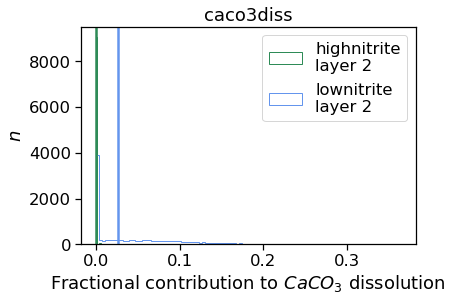

In [4]:
chunk1 = "highnitrite"
chunk2 = "lownitrite"
layer1 = 2
layer2 = 2
param = "caco3diss"
label1 = f"{chunk1}\nlayer {layer1}"
label2 = f"{chunk2}\nlayer {layer2}"

fig, ax  = plt.subplots()
testsignificance(ax, chunk1, chunk2, layer1, layer2, param,
                dispxlabel=True, dispylabel=True, disptitle = True)

In [55]:
layers = np.array([25.8, 26.1, 26.35, 26.5,27.2], dtype=float)  # in sigma0
divider = 2  # Number of sublayers in each layer
sl = np.zeros((len(layers) - 1, divider + 1))
for i in np.arange(0, len(layers) - 1):
    sl[i,] = np.linspace(layers[i], layers[i + 1], divider + 1)
sublayers = np.unique(sl)
ylabels = []
sublayers

array([25.8  , 25.95 , 26.1  , 26.225, 26.35 , 26.425, 26.5  , 26.85 ,
       27.2  ])

chunkhighnitrite layer 0 variance = 0.003752621831578692
chunklownitrite layer 0 variance = 0.002084077712458861
t test T = -76.48422045539516
t test p = 0.0
Mann-Whitney U = 22275385.0
Mann-Whitney p = 0.0
chunkhighnitrite layer 0 variance = 0.0019272958961608193
chunklownitrite layer 0 variance = 0.00013394825422288027
t test T = 153.90071671893995
t test p = 0.0
Mann-Whitney U = 90967982.5
Mann-Whitney p = 0.0
chunkhighnitrite layer 0 variance = 9.768052862399571e-06
chunklownitrite layer 0 variance = 5.319166469578434e-07
t test T = 81.63173360523305
t test p = 0.0
Mann-Whitney U = 74453473.0
Mann-Whitney p = 0.0
chunkhighnitrite layer 0 variance = 5.259886121913338e-06
chunklownitrite layer 0 variance = 2.7721129642905028e-06
t test T = -132.97469866667794
t test p = 0.0
Mann-Whitney U = 9201511.0
Mann-Whitney p = 0.0
chunkhighnitrite layer 0 variance = 0.004133450097631697
chunklownitrite layer 0 variance = 0.002241563161798031
t test T = -12.888881680355775
t test p = 7.58467242

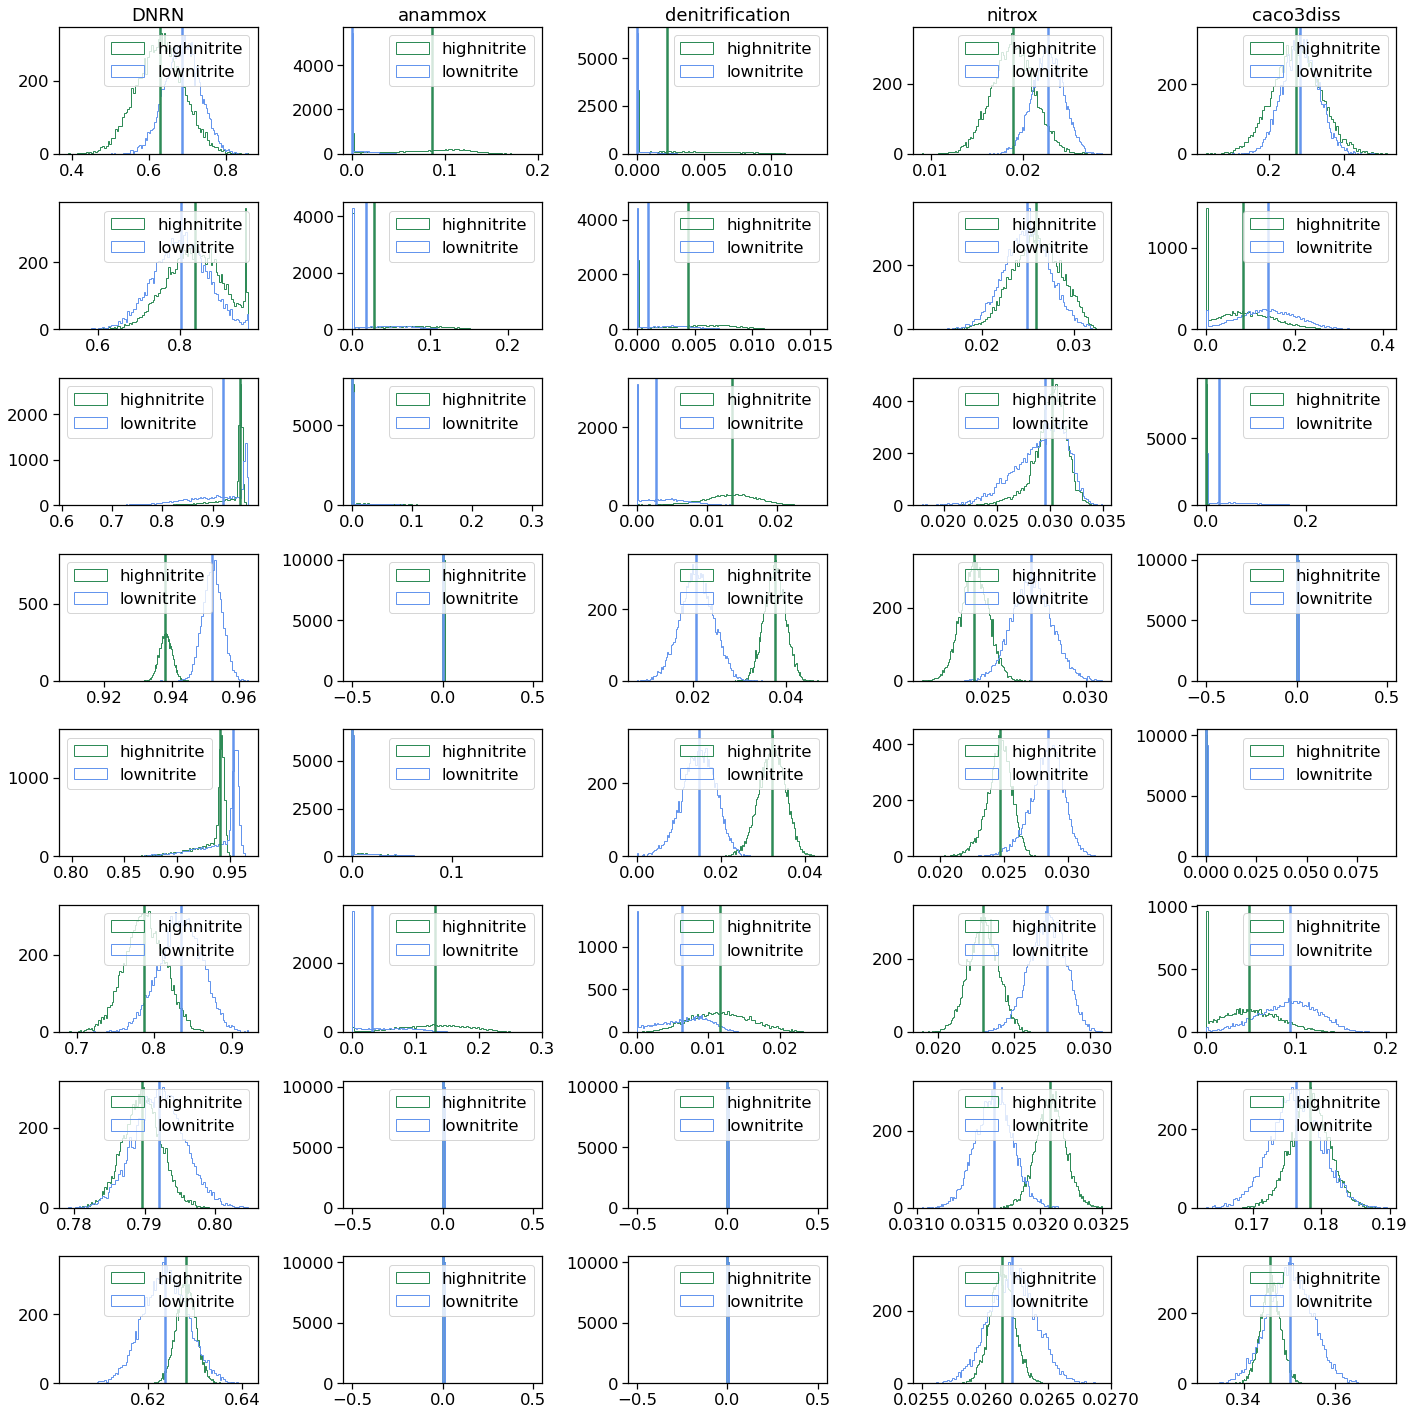

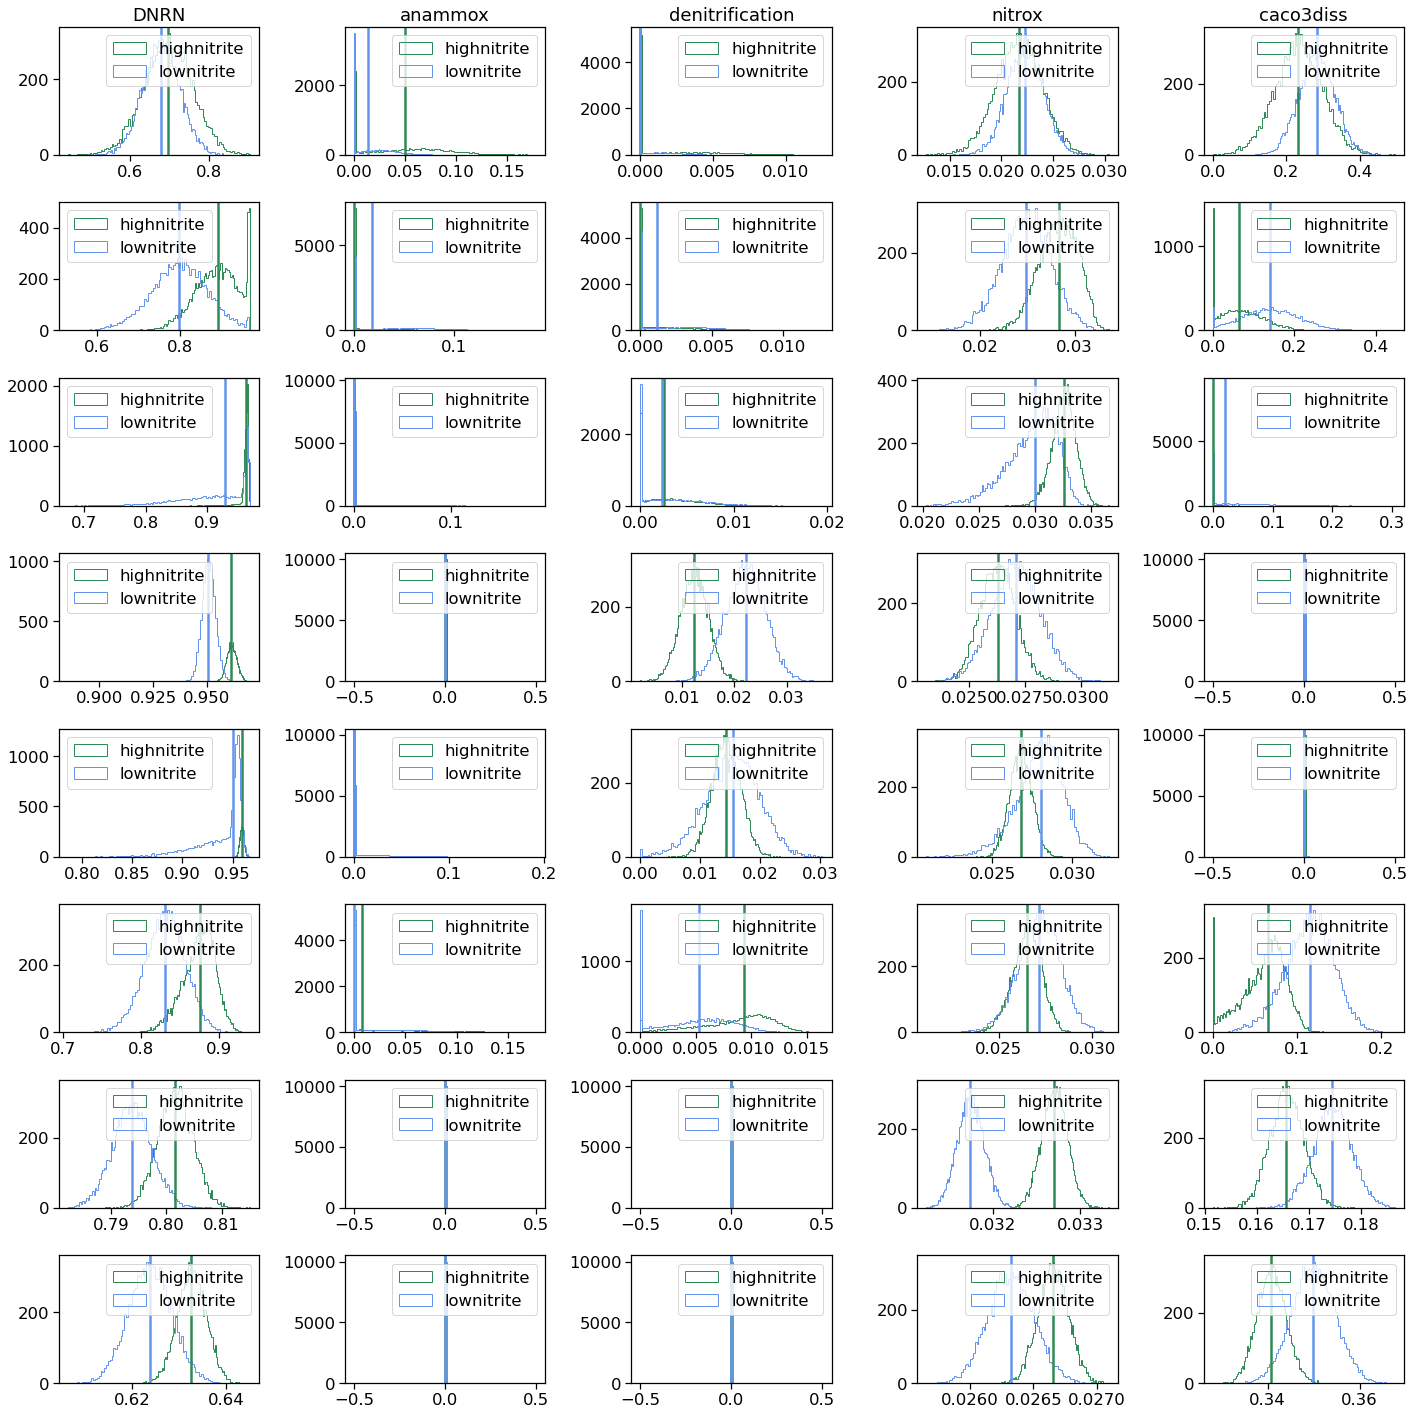

In [5]:
chunk1 = "highnitrite"
chunk2 = "lownitrite"
param = "caco3diss"
layers = np.array([25.8, 26.1, 26.35, 26.5,27.2], dtype=float)  # in sigma0
divider = 2  # Number of sublayers in each layer

params = ["DNRN","anammox","denitrification",
            "nitrox","caco3diss"]

layers = np.array([25.8, 26.1, 26.35, 26.5,27.2], dtype=float)  # in sigma0
divider = 2  # Number of sublayers in each layer
sl = np.zeros((len(layers) - 1, divider + 1))
for i in np.arange(0, len(layers) - 1):
    sl[i,] = np.linspace(layers[i], layers[i + 1], divider + 1)
sublayers = np.unique(sl)
ylabels = []

for i in range(len(sublayers)-1):
    label = fr"{sublayers[i]:.4} - {sublayers[i+1]:.4}"
    ylabels.append(label)
nlayers = len(ylabels)

ttestoutput = np.ones((nlayers,5))
mannwhitneyoutput = np.ones((nlayers,5))

fig, axes = plt.subplots(nlayers, len(params), figsize = (20,20))

for i in range(0,nlayers):
    layer1 = i
    layer2 = i
    label1 = f"{chunk1}"
    label2 = f"{chunk2}"
    
    for count, p in enumerate(params):
        ax = axes[i, count]
        if i==0:
            ttestT, ttestp, mannwhitneyU, mannwhitneyp = testsignificance(ax, chunk1, chunk2, layer1, layer2, p,
                                                                         disptitle = True)
        else:
            ttestT, ttestp, mannwhitneyU, mannwhitneyp = testsignificance(ax, chunk1, chunk2, layer1, layer2, p)
        ttestoutput[i, count] = ttestp
        mannwhitneyoutput[i, count] = mannwhitneyp
        
plt.tight_layout()
plt.savefig("stats/high vs low nitrite.pdf")

In [6]:
mannwhitneyoutput = pd.DataFrame(mannwhitneyoutput,
            columns = params)
mannwhitneyoutput["layer"] = ylabels
mannwhitneyoutput = mannwhitneyoutput.set_index("layer")
mannwhitneyoutput.to_excel("stats/Mann-Whitney test high vs low nitrite.xlsx")
mannwhitneyoutput

,DNRN,anammox,denitrification,nitrox,caco3diss
layer,,,,,
25.8 - 25.95,0.000000e+00,0.000000e+00,0.0,0.000000e+00,9.043796e-37
25.95 - 26.1,2.422304e-258,3.383052e-53,0.0,1.701936e-171,0.000000e+00
26.1 - 26.23,4.147159e-135,6.896050e-13,0.0,4.929338e-137,0.000000e+00
26.23 - 26.35,0.000000e+00,2.694777e-03,0.0,0.000000e+00,1.000000e+00
26.35 - 26.43,0.000000e+00,8.416748e-01,0.0,0.000000e+00,2.911871e-184
26.43 - 26.5,0.000000e+00,0.000000e+00,0.0,0.000000e+00,0.000000e+00
26.5 - 26.85,0.000000e+00,1.000000e+00,1.0,0.000000e+00,0.000000e+00
26.85 - 27.2,0.000000e+00,1.000000e+00,1.0,4.519306e-285,0.000000e+00


In [7]:
ttestoutput = pd.DataFrame(ttestoutput,
            columns = params)
ttestoutput["layer"] = ylabels
ttestoutput = ttestoutput.set_index("layer")
ttestoutput.to_excel("stats/T test high vs low nitrite.xlsx")
ttestoutput

,DNRN,anammox,denitrification,nitrox,caco3diss
layer,,,,,
25.8 - 25.95,0.000000e+00,0.000000e+00,0.0,0.000000e+00,7.584672e-38
25.95 - 26.1,5.234662e-276,1.477499e-115,0.0,6.449934e-178,0.000000e+00
26.1 - 26.23,0.000000e+00,7.359354e-03,0.0,1.743218e-210,0.000000e+00
26.23 - 26.35,0.000000e+00,2.012709e-02,0.0,0.000000e+00,NaN
26.35 - 26.43,8.886977e-291,4.329989e-12,0.0,0.000000e+00,1.249396e-108
26.43 - 26.5,0.000000e+00,0.000000e+00,0.0,0.000000e+00,0.000000e+00
26.5 - 26.85,0.000000e+00,NaN,NaN,0.000000e+00,0.000000e+00
26.85 - 27.2,0.000000e+00,NaN,NaN,2.644107e-302,0.000000e+00


In [15]:
ylabels

['25.8 - 25.95',
 '25.95 - 26.1',
 '26.1 - 26.23',
 '26.23 - 26.35',
 '26.35 - 26.43',
 '26.43 - 26.5',
 '26.5 - 26.85',
 '26.85 - 27.2']

127390.99716126079 0.0
20276.231362527797 0.0
235645.99076100255 0.0
76949.04948934147 0.0
149602.83606613375 0.0
98317.53092607883 0.0
4190.535088692776 0.0
78396.81919280667 0.0
30377.21816142878 0.0
119016.33541495667 0.0


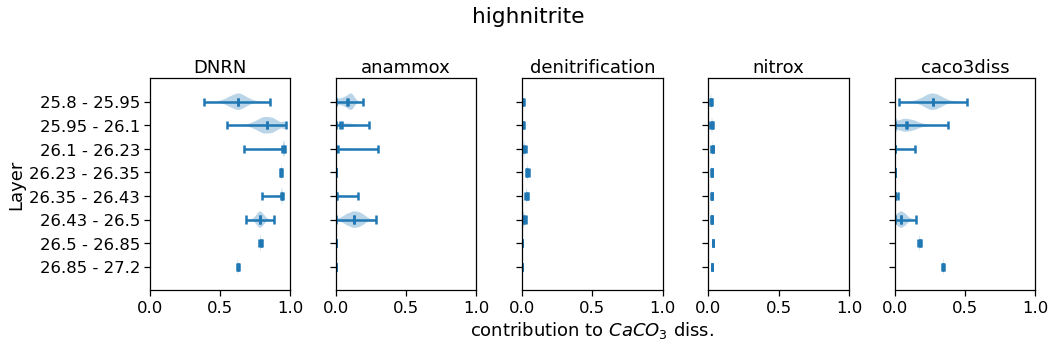

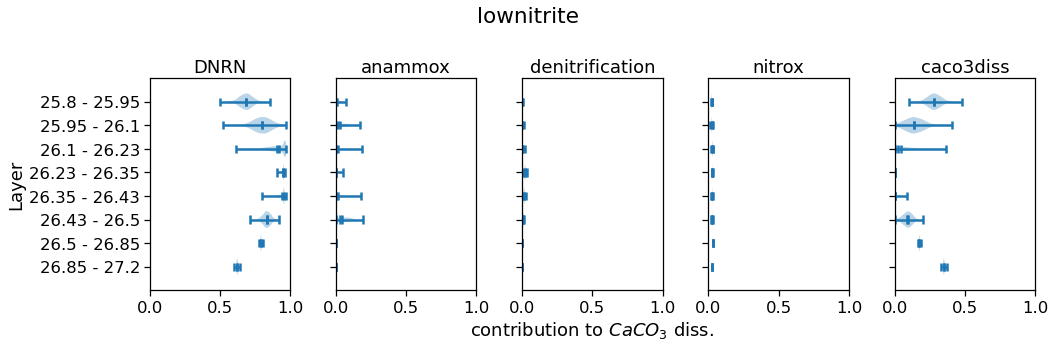

In [14]:
chunks = ["highnitrite", "lownitrite"]
params = ["DNRN","anammox","denitrification",
            "nitrox","caco3diss"]

ANOVAoutput = np.ones((len(chunks),len(params)))
columndict = {'# DNRN':"DNRN",
              ' Anammox':"anammox",
              ' Denitrification':"denitrification",
              ' Nitrite Oxidation':"nitrox",
              ' CaCO3 Dissolution ':"caco3diss"}

for i, chunk in enumerate(chunks):
    fig, axes = plt.subplots(1,5, figsize =(15,5), sharey=True)
    for count, param in enumerate(params):
        df0 = pd.read_csv(f"output/chunk{chunk}/layer0_coeff_iter.csv").rename(columns = columndict)
        df1 = pd.read_csv(f"output/chunk{chunk}/layer1_coeff_iter.csv").rename(columns = columndict)
        df2 = pd.read_csv(f"output/chunk{chunk}/layer2_coeff_iter.csv").rename(columns = columndict)
        df3 = pd.read_csv(f"output/chunk{chunk}/layer3_coeff_iter.csv").rename(columns = columndict)
        df4 = pd.read_csv(f"output/chunk{chunk}/layer4_coeff_iter.csv").rename(columns = columndict)
        df5 = pd.read_csv(f"output/chunk{chunk}/layer5_coeff_iter.csv").rename(columns = columndict)
        df6 = pd.read_csv(f"output/chunk{chunk}/layer6_coeff_iter.csv").rename(columns = columndict)
        df7 = pd.read_csv(f"output/chunk{chunk}/layer7_coeff_iter.csv").rename(columns = columndict)

        arr0 = np.array(df0[param])
        arr1 = np.array(df1[param])
        arr2 = np.array(df2[param])
        arr3 = np.array(df3[param])
        arr4 = np.array(df4[param])
        arr5 = np.array(df5[param])
        arr6 = np.array(df6[param])
        arr7 = np.array(df7[param])
        
        df = pd.DataFrame([arr0,arr1,arr2,arr3,arr4,arr5,arr6,arr7]).T
        df.rename(columns = dict(zip(list(range(0,8)),ylabels)))
        ax = axes[count]
        ax.violinplot(df, points=80, vert=False, widths=0.7,
                     showmeans=True, showextrema=True, showmedians=True)
        ax.set_ylim([9,0])
        ax.set_xlim([0,1.0])
        ax.set_yticks(list(range(1,9)))
        ax.set_yticklabels(ylabels)
        ax.set_title(param)
        if count==0:
            ax.set_ylabel("Layer")
        elif count==2:
            ax.set_xlabel("contribution to $CaCO_3$ diss.")

        F, p = stats.f_oneway(arr0,arr1,arr2,arr3,arr4,arr5,arr6,arr7)
        print(F,p)

        ANOVAoutput[i,count] = p
    fig.suptitle(f"{chunk}")
    plt.tight_layout()
    plt.savefig(f"stats/chunk{chunk} violinplot.pdf")

In [9]:
ANOVAoutput = pd.DataFrame(ANOVAoutput,
            columns = params)
ANOVAoutput["chunk"] = chunks
ANOVAoutput = ANOVAoutput.set_index("chunk")
ANOVAoutput.to_excel("stats/ANOVA.xlsx")
ANOVAoutput

,DNRN,anammox,denitrification,nitrox,caco3diss
chunk,,,,,
highnitrite,1.0,1.0,1.0,1.0,1.0
lownitrite,1.0,1.0,1.0,1.0,1.0
